# Getting Started

This guide covers the core FactoriaX workflow end-to-end:

- Introduction to Factoriax.
- Breakdown of the observation space and action space.
- Running rollouts: Python loop, vmap, and lax.scan.
- Play a game through the interface.
- Scenarios (easy rocket).
- Saving replays.
- Creating visualizations and replays.

**Prerequisites**: install the package with `uv sync` (or `pip install factoriax`).

## Introduction

FactoriaX is a JAX-native reinforcement-learning environment inspired by Factorio.
The goal is to automate production lines and ultimately launch a rocket, starting
from raw ore and progressing through smelting, assembly, and science research.

The environment follows the [gymnax](https://github.com/RobertTLange/gymnax) API.
A stateless `env` object and an `EnvParams` struct hold all configuration.
`env.reset_env` and `env.step_env` take explicit JAX keys and states and are
fully JIT-compilable and `jax.vmap`-able.

```python
env, params = env_from_name("EasyRocket-v1")
obs, state  = env.reset_env(key, params)
obs, state, reward, done, info = env.step_env(key, state, action, params)
```

In [82]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from factoriax.make import env_from_name

env, params = env_from_name("EasyRocket-v1")
obs, state = env.reset_env(jax.random.PRNGKey(0), params)

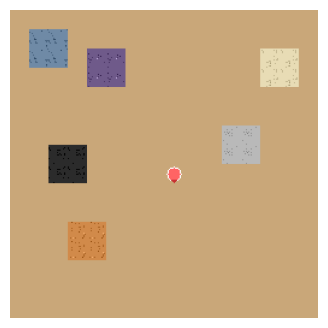

In [83]:
from factoriax.engine.jax_renderer import JaxRenderer

plt.figure(figsize=(4, 4))
plt.imshow(np.asarray(JaxRenderer(tile_px=16).jit_render_map(state)))
plt.axis("off")
plt.show()

## Observation space

FactoriaX supports two types of observation: **vector** and **image**.

**Vector observations** are flat float arrays returned directly by `reset_env` and
`step_env`. They are fully JIT-compatible and the standard input for neural-network
policies. Four variants are available:

| Variant | View | Shape | Notes |
|---------|------|-------|-------|
| `x_ray_global` | whole map | `(H*W*10 + 72,)` | sees slot contents and buried ore |
| `x_ray_local` | `(2r+1)×(2r+1)` window | `((2r+1)^2*10 + 72,)` | centred on player, `obs_radius` sets `r` |
| `superficial_global` | whole map | `(H*W*3 + 63,)` | only visible surface |
| `superficial_local` | `(2r+1)×(2r+1)` window | `((2r+1)^2*3 + 63,)` | centred on player |

**Image observations** are RGB arrays produced by `factoriax.engine.observations.rgb`.
They are not JIT-compatible and are intended for vision-based agents or visual
inspection.

Pass `obs=` to `env_from_name` to select a vector variant, and `obs_radius=` for
local variants.

In [84]:
# --- Vector observations ---
env_xg, params_xg = env_from_name("EasyRocket-v1", obs="x_ray_global")
env_xl, params_xl = env_from_name("EasyRocket-v1", obs="x_ray_local", obs_radius=5)
env_sg, params_sg = env_from_name("EasyRocket-v1", obs="superficial_global")
env_sl, params_sl = env_from_name("EasyRocket-v1", obs="superficial_local", obs_radius=5)

key = jax.random.PRNGKey(0)
obs_xg, _ = env_xg.reset_env(key, params_xg)
obs_xl, _ = env_xl.reset_env(key, params_xl)
obs_sg, _ = env_sg.reset_env(key, params_sg)
obs_sl, _ = env_sl.reset_env(key, params_sl)

print("x_ray_global shape:         ", obs_xg.shape)
print("x_ray_local (r=5) shape:    ", obs_xl.shape)
print("superficial_global shape:   ", obs_sg.shape)
print("superficial_local (r=5):    ", obs_sl.shape)
print()
print("dtype:", obs_xg.dtype, "  range: [", float(obs_xg.min()), ",", float(obs_xg.max()), "]")

x_ray_global shape:          (2632,)
x_ray_local (r=5) shape:     (1282,)
superficial_global shape:    (831,)
superficial_local (r=5):     (426,)

dtype: float32   range: [ 0.0 , 1.0 ]


Image obs shape: (512, 512, 3)   dtype: uint8
Note: rgb() is not JIT-compatible.


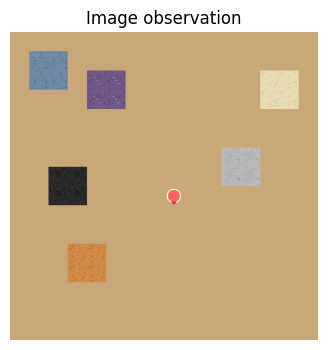

In [85]:
# --- Image observation ---
from factoriax.engine.observations import rgb

img_obs = rgb(state, block_pixel_size=32)

print("Image obs shape:", img_obs.shape, "  dtype:", img_obs.dtype)
print("Note: rgb() is not JIT-compatible.")

plt.figure(figsize=(4, 4))
plt.imshow(img_obs)
plt.axis("off")
plt.title("Image observation")
plt.show()

## Action space

Actions are flat integers. The space has **85 actions** split into five families:

| Family | Offsets | Count | Actions |
|--------|---------|-------|---------|
| Move / face | 0 – 8 | 9 | `NOOP`, `UP/DOWN/LEFT/RIGHT`, `FACE_UP/DOWN/LEFT/RIGHT` |
| Interact | 9 – 16 | 8 | `MINE`, `PICKUP`, `WITHDRAW`, `REPAIR`, `ROTATE_LEFT/RIGHT/UP/DOWN` |
| Place | 17 – 26 | 10 | `PLACE_<machine>`, one per placeable machine type |
| Craft | 27 – 52 | 26 | `CRAFT_<item>`, one per craftable item |
| Deposit | 53 – 84 | 32 | `DEPOSIT_<item>`, one per non-empty item |

Each action is **self-contained**: placement names the machine, deposit names the
item, so no slot cursor is needed. Invalid actions (e.g. placing on water) are
silently ignored.

In [86]:
from factoriax.engine.constants import (
    Action, MoveAction, InteractAction,
    NUM_ACTIONS, PLACE_BASE, CRAFT_BASE, DEPOSIT_BASE,
    PLACEMENT_ITEMS, CRAFT_ITEMS, DEPOSIT_ITEMS,
)

print(f"Total actions : {NUM_ACTIONS}")
print(f"Move          : 0 – {len(MoveAction) - 1}  ({len(MoveAction)} actions)")
print(f"Interact      : {len(MoveAction)} – {PLACE_BASE - 1}  ({len(InteractAction)} actions)")
print(f"Place         : {PLACE_BASE} – {CRAFT_BASE - 1}  ({len(PLACEMENT_ITEMS)} actions)")
print(f"Craft         : {CRAFT_BASE} – {DEPOSIT_BASE - 1}  ({len(CRAFT_ITEMS)} actions)")
print(f"Deposit       : {DEPOSIT_BASE} – {NUM_ACTIONS - 1}  ({len(DEPOSIT_ITEMS)} actions)")
print()
print("Place actions:", [a.name for a in Action if a.name.startswith("PLACE_")])

Total actions : 85
Move          : 0 – 8  (9 actions)
Interact      : 9 – 16  (8 actions)
Place         : 17 – 26  (10 actions)
Craft         : 27 – 52  (26 actions)
Deposit       : 53 – 84  (32 actions)

Place actions: ['PLACE_MINER', 'PLACE_PALLET', 'PLACE_CONVEYOR_BELT', 'PLACE_ASSEMBLER', 'PLACE_ARM', 'PLACE_ROCKET', 'PLACE_FURNACE', 'PLACE_SCIENCE_LAB', 'PLACE_SPLITTER', 'PLACE_CROSSING']


## Running rollouts

The recommended setup for training is `jax.jit(jax.vmap(rollout))`. It is one compiled [XLA kernel](https://openxla.org/xla/gpu_architecture) (hopefully running on your [GPU](https://media1.tenor.com/m/N2hV1al2rjcAAAAd/if-i-had-one-angry.gif)) that runs N environments in parallel for T steps, called once per batch from Python. The tradeoff is GPU memory versus speed. Experiment with episode length and batch size during training to find optimal settings for your hardware. 

The rest of this section shows more detail on how the pattern is built one step at a time. The figure below shows you the impact of the scan, vmapping and changing batch size. 

### The full pattern

In [87]:
import time
from factoriax.engine.constants import Action

NOOP    = int(Action.NOOP)
N_ENVS  = 32
N_STEPS = 500
N_REPS  = 3

def scan_body(carry, _):
    key, state = carry
    key, sk = jax.random.split(key)
    _, state, reward, _, _ = env.step_env(sk, state, NOOP, params)
    return (key, state), reward

def rollout(key):
    _, state = env.reset_env(key, params)
    (_, state), rewards = jax.lax.scan(scan_body, (key, state), None, length=N_STEPS)
    return rewards

collect = jax.jit(jax.vmap(rollout))

### Building it up

Each step adds one layer. JIT is always on.

#### 1. JIT only

`jax.jit(step_env)` compiles the step function once. Python still drives the loop, so throughput is bounded by the host dispatch rate.

In [88]:
LOOP_STEPS = 50

step_jit = jax.jit(env.step_env)

def run_loop(key):
    _, state = env.reset_env(key, params)
    for _ in range(LOOP_STEPS):
        key, sk = jax.random.split(key)
        _, state, _, _, _ = step_jit(sk, state, NOOP, params)
    jax.block_until_ready(state.player_inventory)

t0 = time.perf_counter()
run_loop(jax.random.PRNGKey(0))
loop_startup = time.perf_counter() - t0

t0 = time.perf_counter()
for i in range(1, N_REPS + 1):
    run_loop(jax.random.PRNGKey(i))
loop_steady = (time.perf_counter() - t0) / N_REPS
loop_sps    = LOOP_STEPS / loop_steady

print(f"startup {loop_startup:.1f}s   steady {loop_steady:.3f}s   {loop_sps:,.0f} steps/s")

startup 6.5s   steady 0.170s   294 steps/s


#### 2. Replace the loop with `lax.scan`

`jax.lax.scan` compiles the full T-step rollout into one XLA program. Python makes one call per episode. No per-step dispatch overhead.

In [89]:
run_scan = jax.jit(rollout)

t0 = time.perf_counter()
jax.block_until_ready(run_scan(jax.random.PRNGKey(0)))
scan_startup = time.perf_counter() - t0

t0 = time.perf_counter()
for i in range(1, N_REPS + 1):
    jax.block_until_ready(run_scan(jax.random.PRNGKey(i)))
scan_steady = (time.perf_counter() - t0) / N_REPS
scan_sps    = N_STEPS / scan_steady

print(f"startup {scan_startup:.1f}s   steady {scan_steady:.3f}s   {scan_sps:,.0f} steps/s")

startup 5.2s   steady 0.047s   10,634 steps/s


#### 3. Vectorise across environments with `vmap`

`jax.vmap(rollout)` maps the scan over N independent keys in one kernel call. `collect` is the function defined in the full pattern above.

In [90]:
collect_32  = jax.jit(jax.vmap(rollout))
collect_128 = jax.jit(jax.vmap(rollout))

for n, col, label in [(N_ENVS, collect_32, "32 envs"), (128, collect_128, "128 envs")]:
    keys = jax.random.split(jax.random.PRNGKey(0), n)
    t0 = time.perf_counter()
    jax.block_until_ready(col(keys))
    startup = time.perf_counter() - t0

    t0 = time.perf_counter()
    for i in range(1, N_REPS + 1):
        jax.block_until_ready(col(jax.random.split(jax.random.PRNGKey(i * 100), n)))
    steady = (time.perf_counter() - t0) / N_REPS
    sps    = N_STEPS * n / steady

    if n == N_ENVS:
        vmap_startup, vmap_sps = startup, sps
    else:
        vmap_startup_128, vmap_sps_128 = startup, sps

    print(f"vmap(scan) {label:10s}  startup {startup:.1f}s   steady {steady:.3f}s   {sps:,.0f} steps/s")

vmap(scan) 32 envs     startup 6.3s   steady 0.045s   358,843 steps/s
vmap(scan) 128 envs    startup 5.5s   steady 0.051s   1,260,578 steps/s


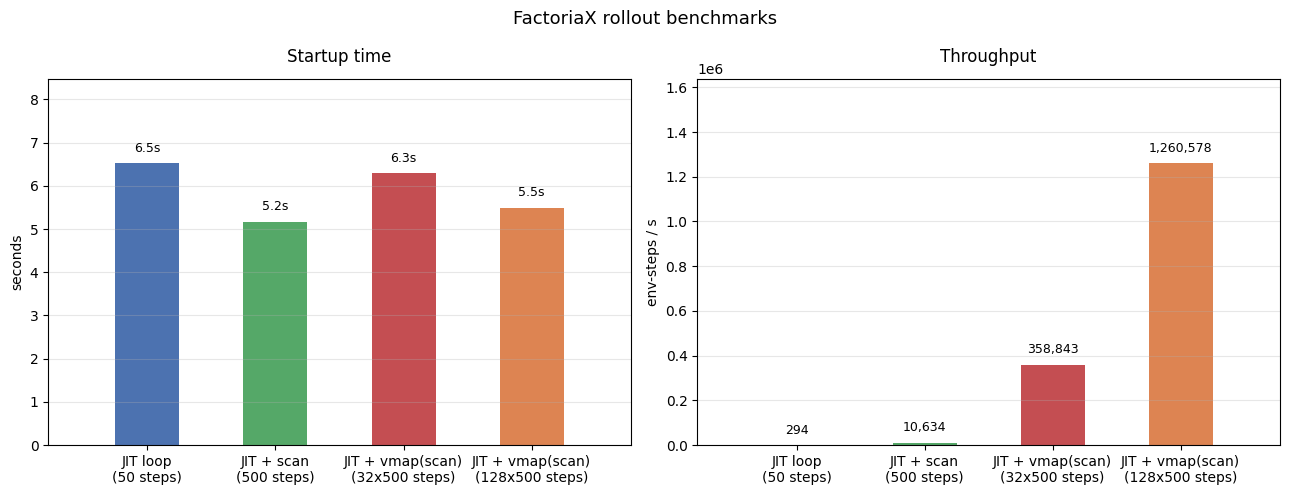

In [91]:
labels      = [
    f"JIT loop\n({LOOP_STEPS} steps)",
    f"JIT + scan\n({N_STEPS} steps)",
    f"JIT + vmap(scan)\n({N_ENVS}x{N_STEPS} steps)",
    f"JIT + vmap(scan)\n(128x{N_STEPS} steps)",
]
startups    = [loop_startup, scan_startup, vmap_startup,     vmap_startup_128]
throughputs = [loop_sps,     scan_sps,     vmap_sps,         vmap_sps_128]
colours     = ["#4c72b0",    "#55a868",    "#c44e52",         "#dd8452"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, vals, title, ylabel in [
    (ax1, startups,    "Startup time",  "seconds"),
    (ax2, throughputs, "Throughput",    "env-steps / s"),
]:
    bars = ax.bar(labels, vals, color=colours, width=0.5)
    ax.set_title(title, pad=12)
    ax.set_ylabel(ylabel)
    ax.margins(x=0.15)
    top = max(vals)
    ax.set_ylim(0, top * 1.3)
    ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        fmt = f"{v:.1f}s" if ax is ax1 else f"{v:,.0f}"
        ax.text(bar.get_x() + bar.get_width() / 2, v + top * 0.03,
                fmt, ha="center", va="bottom", fontsize=9)

fig.suptitle("FactoriaX rollout benchmarks", fontsize=13)
plt.tight_layout()
plt.show()

## Play a game through the interface

FactoriaX ships a pygame-based interactive client that lets you play the game
manually. It is useful for understanding the mechanics and building intuition before
designing reward functions.

Launch it from a terminal (not from inside a notebook):

```bash
python -m factoriax.playground.play
```

**Controls:**

| Key | Action |
|-----|--------|
| W A S D | Move player |
| Space | Mine ore at current tile |
| E | Place or pick up machine, transfer items to machine, or craft item |
| F | Inspect machine in front of player |
| I | Toggle inventory / crafting menu |
| A / D | Select inventory slot (wraps to crafting panel) |
| W / S | Navigate rows in inventory / crafting panel |
| P | Toggle achievement menu |
| 1–8 | Quick-select inventory slot |
| Shift+1–2 | Quick-select slots 9–10 |
| Ctrl+1–9 | Switch active player |
| Escape | Close menu / open pause menu |

The pygame client does **not** import the JAX training pipeline, so it starts
quickly and does not require a GPU.

You can also run the playable interface through python:

In [3]:
from factoriax.playground.play.main import main
main()

pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Scenarios

FactoriaX registers scenarios with gymnax-style version ids. Two are built in:

| Id | Name | Map | Notes |
|----|------|-----|-------|
| `EasyRocket-v1` | Easy Rocket | 16×16 | Procgen map, 2000-step budget, fresh layout each episode (`resample=True`) |
| `Rocket-v1` | Rocket | 32×32 | Fixed map, furnace and assembler pre-placed, hand-craft masked, 8000-step budget |

`resample=True` means each `auto_reset` draws a fresh map rather than restoring
the initial state, which is important for curriculum learning and generalisation.

In [ ]:
from factoriax.engine.envs.registry import list_scenarios

for env_id, spec in list_scenarios():
    print(f"{env_id:20s}  resample={spec.resample}")
    print(f"  {spec.description}")
    print()

In [ ]:
# auto_reset=True wraps the env in AutoResetWrapper.
# reset_env is called automatically whenever done is True.

env_ar, params_ar = env_from_name("EasyRocket-v1", auto_reset=True)

key, reset_key = jax.random.split(jax.random.PRNGKey(7))
obs_ar, state_ar = env_ar.reset_env(reset_key, params_ar)

key, step_key = jax.random.split(key)
obs_ar, state_ar, reward, done, info = env_ar.step_env(
    step_key, state_ar, int(Action.NOOP), params_ar
)

print("reward:", float(reward), "  done:", bool(done))

## Saving replays

A `Trajectory` bundles actions and (optionally) full state arrays from an episode.
It saves to a compressed `.npz` file and round-trips via `Trajectory.save` and
`Trajectory.load`.

For training loops, `RolloutRecorder` slots in alongside your `collect_fn` with
zero changes to JIT'd code. Call `recorder.record(trajectories, env_states)` after
each collection step and `recorder.finish()` when done.

In [13]:
from factoriax.analysis.trajectory import Trajectory

env_r, params_r = env_from_name("EasyRocket-v1")
key = jax.random.PRNGKey(42)
key, reset_key = jax.random.split(key)
_, state_r = env_r.reset_env(reset_key, params_r)

step_jit = jax.jit(env_r.step_env)

T = 10
actions_list = []

for _ in range(T):
    key, step_key = jax.random.split(key)
    _, state_r, _, _, _ = step_jit(step_key, state_r, int(Action.NOOP), params_r)
    actions_list.append(int(Action.NOOP))

traj = Trajectory(actions=np.array(actions_list))
print(traj)

Trajectory(episodes=1, steps=10, players=1)


In [12]:
import tempfile
from pathlib import Path

tmp = Path(tempfile.mkdtemp()) / "demo_replay.npz"
traj.save(str(tmp))

loaded = Trajectory.load(str(tmp))
print("Loaded:", loaded)
print("Actions match:", np.array_equal(traj.actions, loaded.actions))

NameError: name 'traj' is not defined

## Creating visualizations and replays

`compose_frame_with_inventory` concatenates the map render and an inventory
panel side by side, which is the same layout used in training videos.
`write_video` encodes a list of such frames to an MP4 via FFMPEG.

For long rollouts with thousands of frames, use `write_video_streaming` instead.
It writes frames one at a time so peak memory stays bounded to a single frame.

In [ ]:
from factoriax.analysis.video import compose_frame_with_inventory, write_video

env_v, params_v = env_from_name("EasyRocket-v1")
key = jax.random.PRNGKey(99)
key, reset_key = jax.random.split(key)
_, state_v = env_v.reset_env(reset_key, params_v)

step_jit = jax.jit(env_v.step_env)

frames = []
for _ in range(30):
    frames.append(compose_frame_with_inventory(state_v, block_pixel_size=16))
    key, step_key = jax.random.split(key)
    _, state_v, _, _, _ = step_jit(step_key, state_v, int(Action.NOOP), params_v)

print(f"frame shape: {frames[0].shape}  ({len(frames)} frames)")

plt.figure(figsize=(8, 4))
plt.imshow(frames[0])
plt.axis("off")
plt.title("Map + inventory panel")
plt.show()

In [ ]:
video_path = Path(tempfile.mkdtemp()) / "demo.mp4"
write_video(video_path, frames, fps=10)
print("Saved:", video_path)

## Next steps

- {doc}`quick_start`: batched rollouts with `jax.vmap` and PPO training.
- {doc}`../api/index`: full API reference.